# Exploratory Data Analysis (EDA)
**Correlation between Dollar Rate, Crude Oil Prices, Migration & Personal Remittances - Sri Lanka (1994-2025)**

Dataset: `SriLanka_Migration_final.csv` (384 monthly observations, 15 selected columns)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_theme(style='whitegrid', palette='deep')

# Load dataset
df = pd.read_csv('SriLanka_Migration_final.csv')
df['date'] = pd.to_datetime(df['date'])

# Select only the 15 required columns
cols = ['date','slbfe_total_annual','slbfe_male_annual','slbfe_female_annual',
        'slbfe_skilled_annual','slbfe_lowskilled_annual',
        'male_skilled_pct_annual','male_lowskilled_pct_annual',
        'female_skilled_pct_annual','female_lowskilled_pct_annual',
        'avg_age_annual','avg_contract_years_annual',
        'remittances_annual_usd_mn','dollar_rate_monthly','brent_oil_monthly']
df = df[cols]
df['year'] = df['date'].dt.year

# Create annual dataset
annual = df.groupby('year').first().reset_index()
annual['dollar_rate_annual_avg'] = df.groupby('year')['dollar_rate_monthly'].mean().values
annual['brent_oil_annual_avg'] = df.groupby('year')['brent_oil_monthly'].mean().values

annual.rename(columns={
    'slbfe_total_annual': 'emigration',
    'remittances_annual_usd_mn': 'remittances',
    'slbfe_male_annual': 'male',
    'slbfe_female_annual': 'female',
    'slbfe_skilled_annual': 'skilled',
    'slbfe_lowskilled_annual': 'lowskilled'
}, inplace=True)

# Monthly renamed
monthly = df.rename(columns={
    'slbfe_total_annual': 'emigration',
    'remittances_annual_usd_mn': 'remittances',
    'dollar_rate_monthly': 'dollar_rate',
    'brent_oil_monthly': 'brent_oil'
})

print(f'Annual: {annual.shape[0]} years | Monthly: {monthly.shape[0]} observations')

Annual: 32 years | Monthly: 384 observations


## 1. Shapiro-Wilk Normality Test (Annual, n=32)

In [2]:
print('=== Shapiro-Wilk Normality Test ===')
print('Purpose: Assess whether Pearson correlation assumptions are met.')
print(f'{"Variable":25s} {"W Stat":>10s} {"p-value":>12s} {"Result":>18s} {"Implication":>25s}')
print('-' * 95)
for col, name in [('emigration','Emigration'), ('remittances','Remittances'),
                   ('dollar_rate_annual_avg','Dollar Rate'), ('brent_oil_annual_avg','Brent Oil')]:
    w, p = stats.shapiro(annual[col])
    if p > 0.05:
        result = 'Normal (p>0.05)'
        impl = 'Pearson r appropriate'
    else:
        result = 'Non-normal ***'
        impl = 'Consider Spearman r'
    print(f'{name:25s} {w:10.4f} {p:12.4f} {result:>18s} {impl:>25s}')

print('\nNote: Pearson r is reasonably robust to moderate non-normality for n=32.')
print('All reported correlations use Pearson for comparability with literature.')

=== Shapiro-Wilk Normality Test ===
Purpose: Assess whether Pearson correlation assumptions are met.
Variable                      W Stat      p-value             Result               Implication
-----------------------------------------------------------------------------------------------
Emigration                    0.9480       0.1265    Normal (p>0.05)     Pearson r appropriate
Remittances                   0.8594       0.0007     Non-normal ***       Consider Spearman r
Dollar Rate                   0.8285       0.0001     Non-normal ***       Consider Spearman r
Brent Oil                     0.9356       0.0564    Normal (p>0.05)     Pearson r appropriate

Note: Pearson r is reasonably robust to moderate non-normality for n=32.
All reported correlations use Pearson for comparability with literature.


## 2. Pearson Correlation Matrix — Annual Key Variables (n=32)

In [3]:
annual_key = annual[['emigration','remittances','dollar_rate_annual_avg','brent_oil_annual_avg']]
annual_key.columns = ['Emigration','Remittances','Dollar Rate','Oil Price']

corr_annual = annual_key.corr(method='pearson')
print('=== Pearson Correlation Matrix (Annual, n=32) ===')
corr_annual.round(4)

=== Pearson Correlation Matrix (Annual, n=32) ===


,Emigration,Remittances,Dollar Rate,Oil Price
Emigration,1.0000,0.4382,0.4986,0.7070
Remittances,0.4382,1.0000,0.6645,0.6264
Dollar Rate,0.4986,0.6645,1.0000,0.5236
Oil Price,0.7070,0.6264,0.5236,1.0000


## 3. Pairwise Correlations with Significance Tests — Annual (n=32)

In [4]:
cols_list = annual_key.columns
n_vars = len(cols_list)
pval_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)), index=cols_list, columns=cols_list)

for i in range(n_vars):
    for j in range(n_vars):
        if i == j:
            pval_matrix.iloc[i, j] = 0.0
        else:
            r, p = stats.pearsonr(annual_key.iloc[:, i], annual_key.iloc[:, j])
            pval_matrix.iloc[i, j] = p

print('=== P-value Matrix (Annual) ===')
print(pval_matrix.round(6))

print('\n=== Detailed Pairwise Results ===')
for i in range(n_vars):
    for j in range(i+1, n_vars):
        r, p = stats.pearsonr(annual_key.iloc[:, i], annual_key.iloc[:, j])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'  {cols_list[i]:15s} <-> {cols_list[j]:15s}: r = {r:+.4f}, p = {p:.6f} {sig}')

=== P-value Matrix (Annual) ===
             Emigration  Remittances  Dollar Rate  Oil Price
Emigration     0.000000     0.012123     0.003680   0.000006
Remittances    0.012123     0.000000     0.000034   0.000125
Dollar Rate    0.003680     0.000034     0.000000   0.002102
Oil Price      0.000006     0.000125     0.002102   0.000000

=== Detailed Pairwise Results ===
  Emigration      <-> Remittances    : r = +0.4382, p = 0.012123 *
  Emigration      <-> Dollar Rate    : r = +0.4986, p = 0.003680 **
  Emigration      <-> Oil Price      : r = +0.7070, p = 0.000006 ***
  Remittances     <-> Dollar Rate    : r = +0.6645, p = 0.000034 ***
  Remittances     <-> Oil Price      : r = +0.6264, p = 0.000125 ***
  Dollar Rate     <-> Oil Price      : r = +0.5236, p = 0.002102 **


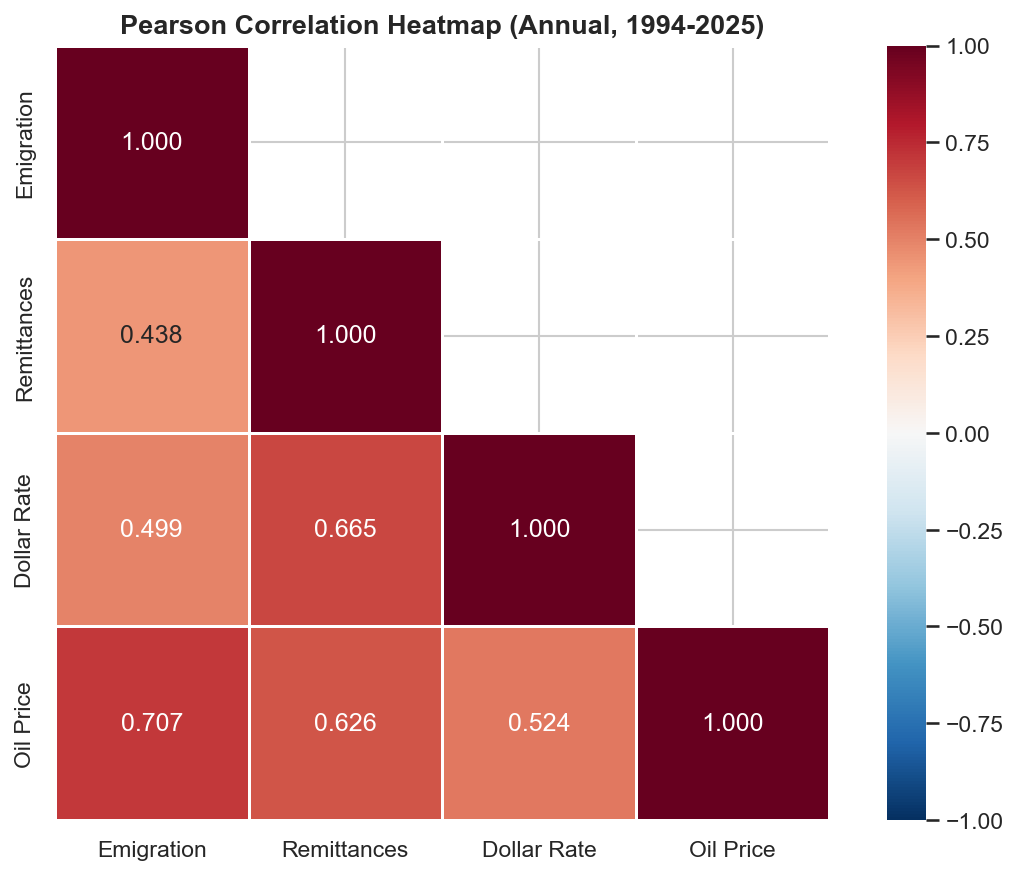

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_annual, dtype=bool), k=1)
sns.heatmap(corr_annual, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Heatmap (Annual, 1994-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corr_heatmap_annual.png')
plt.show()

## 4. Pearson Correlation Matrix — Monthly Variables (n=384)

In [6]:
monthly_key = monthly[['emigration','remittances','dollar_rate','brent_oil']]
monthly_key.columns = ['Emigration','Remittances','Dollar Rate','Oil Price']

corr_monthly = monthly_key.corr(method='pearson')
print('=== Pearson Correlation Matrix (Monthly, n=384) ===')
print(corr_monthly.round(4))

print('\n=== Monthly Pairwise Results ===')
cols_m = monthly_key.columns
for i in range(len(cols_m)):
    for j in range(i+1, len(cols_m)):
        r, p = stats.pearsonr(monthly_key.iloc[:, i], monthly_key.iloc[:, j])
        print(f'  {cols_m[i]:15s} <-> {cols_m[j]:15s}: r = {r:+.4f}, p = {p:.2e} ***')

print('\n=== Annual vs Monthly Comparison ===')
print('All correlations are directionally consistent across both granularities.')
print('Monthly correlations benefit from n=384, resulting in universally p < 0.001.')

=== Pearson Correlation Matrix (Monthly, n=384) ===
             Emigration  Remittances  Dollar Rate  Oil Price
Emigration       1.0000       0.4382       0.4929     0.6827
Remittances      0.4382       1.0000       0.6570     0.6049
Dollar Rate      0.4929       0.6570       1.0000     0.5001
Oil Price        0.6827       0.6049       0.5001     1.0000

=== Monthly Pairwise Results ===
  Emigration      <-> Remittances    : r = +0.4382, p = 1.90e-19 ***
  Emigration      <-> Dollar Rate    : r = +0.4929, p = 6.71e-25 ***
  Emigration      <-> Oil Price      : r = +0.6827, p = 5.16e-54 ***
  Remittances     <-> Dollar Rate    : r = +0.6570, p = 8.48e-49 ***
  Remittances     <-> Oil Price      : r = +0.6049, p = 1.09e-39 ***
  Dollar Rate     <-> Oil Price      : r = +0.5001, p = 1.09e-25 ***

=== Annual vs Monthly Comparison ===
All correlations are directionally consistent across both granularities.
Monthly correlations benefit from n=384, resulting in universally p < 0.001.


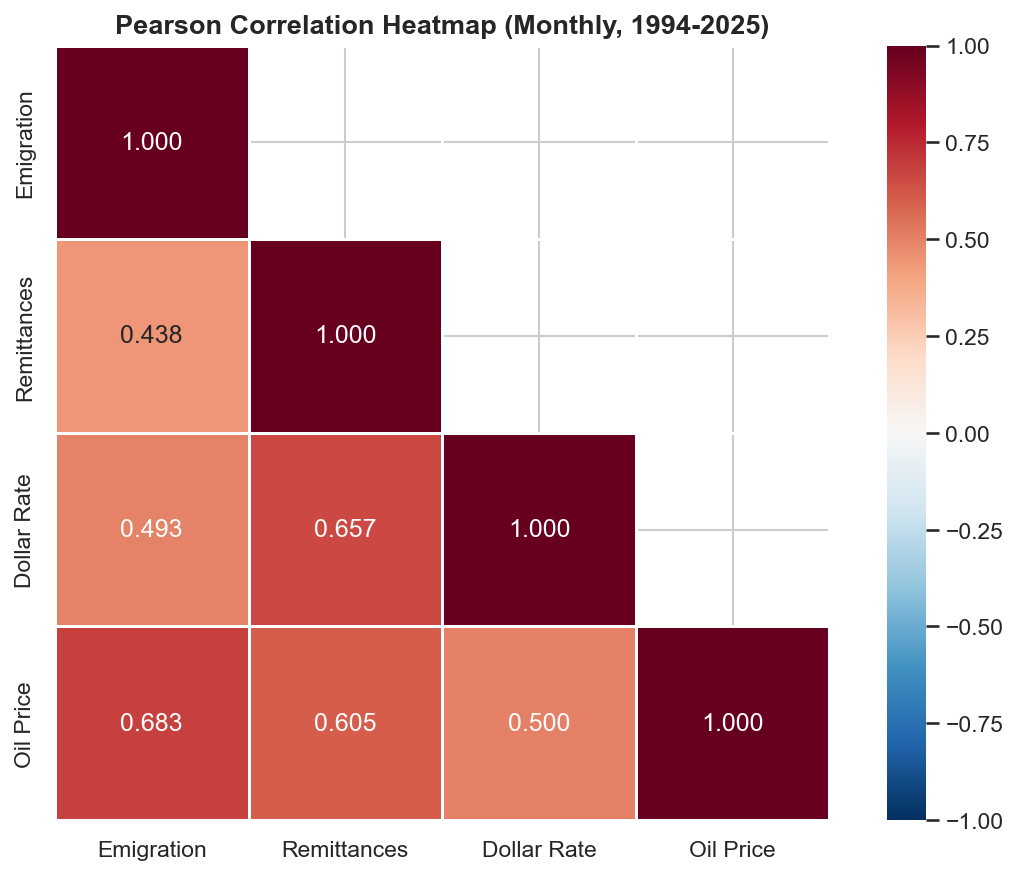

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_monthly, dtype=bool), k=1)
sns.heatmap(corr_monthly, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, ax=ax)
ax.set_title('Pearson Correlation Heatmap (Monthly, 1994-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_corr_heatmap_monthly.png')
plt.show()

## 5. Scatter Plots with Regression Lines — Annual

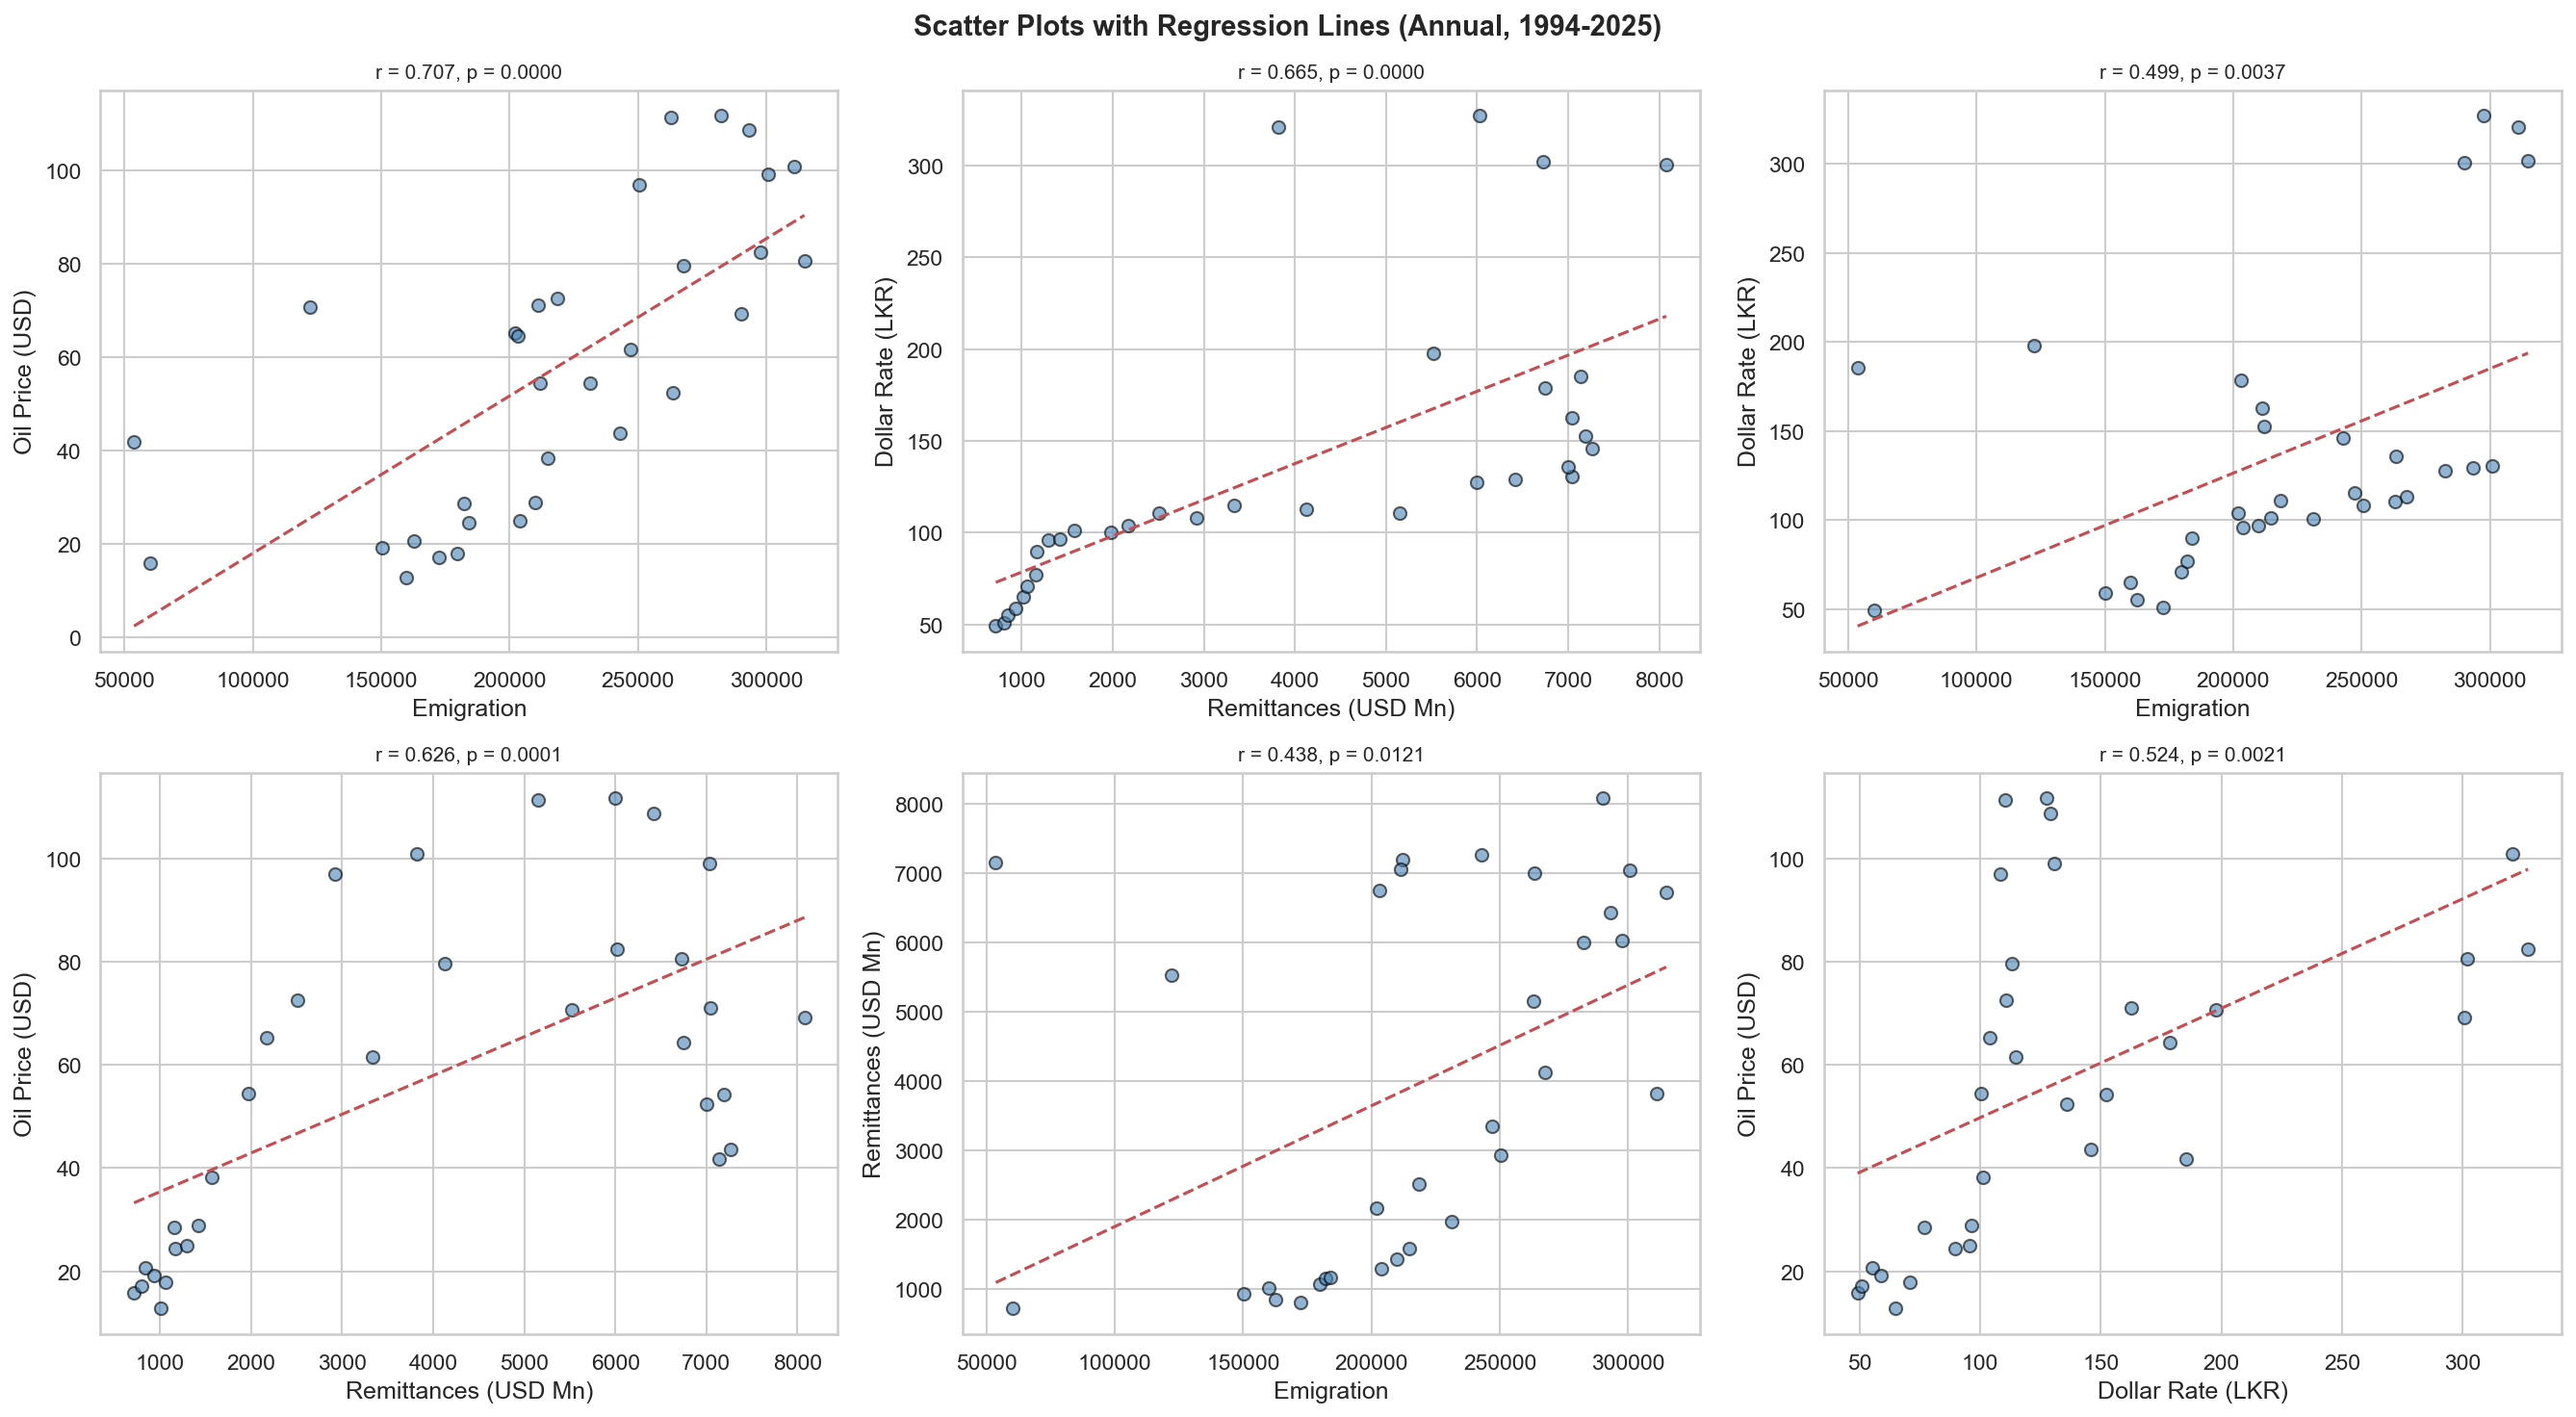

In [8]:
pairs = [
    ('emigration', 'brent_oil_annual_avg', 'Emigration', 'Oil Price (USD)'),
    ('remittances', 'dollar_rate_annual_avg', 'Remittances (USD Mn)', 'Dollar Rate (LKR)'),
    ('emigration', 'dollar_rate_annual_avg', 'Emigration', 'Dollar Rate (LKR)'),
    ('remittances', 'brent_oil_annual_avg', 'Remittances (USD Mn)', 'Oil Price (USD)'),
    ('emigration', 'remittances', 'Emigration', 'Remittances (USD Mn)'),
    ('dollar_rate_annual_avg', 'brent_oil_annual_avg', 'Dollar Rate (LKR)', 'Oil Price (USD)')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scatter Plots with Regression Lines (Annual, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (x, y, xlabel, ylabel) in zip(axes.flat, pairs):
    ax.scatter(annual[x], annual[y], alpha=0.6, color='steelblue', edgecolor='black', s=40)
    z = np.polyfit(annual[x], annual[y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(annual[x].min(), annual[x].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=1.5)
    r, pval = stats.pearsonr(annual[x], annual[y])
    ax.set_title(f'r = {r:.3f}, p = {pval:.4f}', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig('eda_scatter_annual.png')
plt.show()

## 6. Scatter Plots with Regression Lines — Monthly

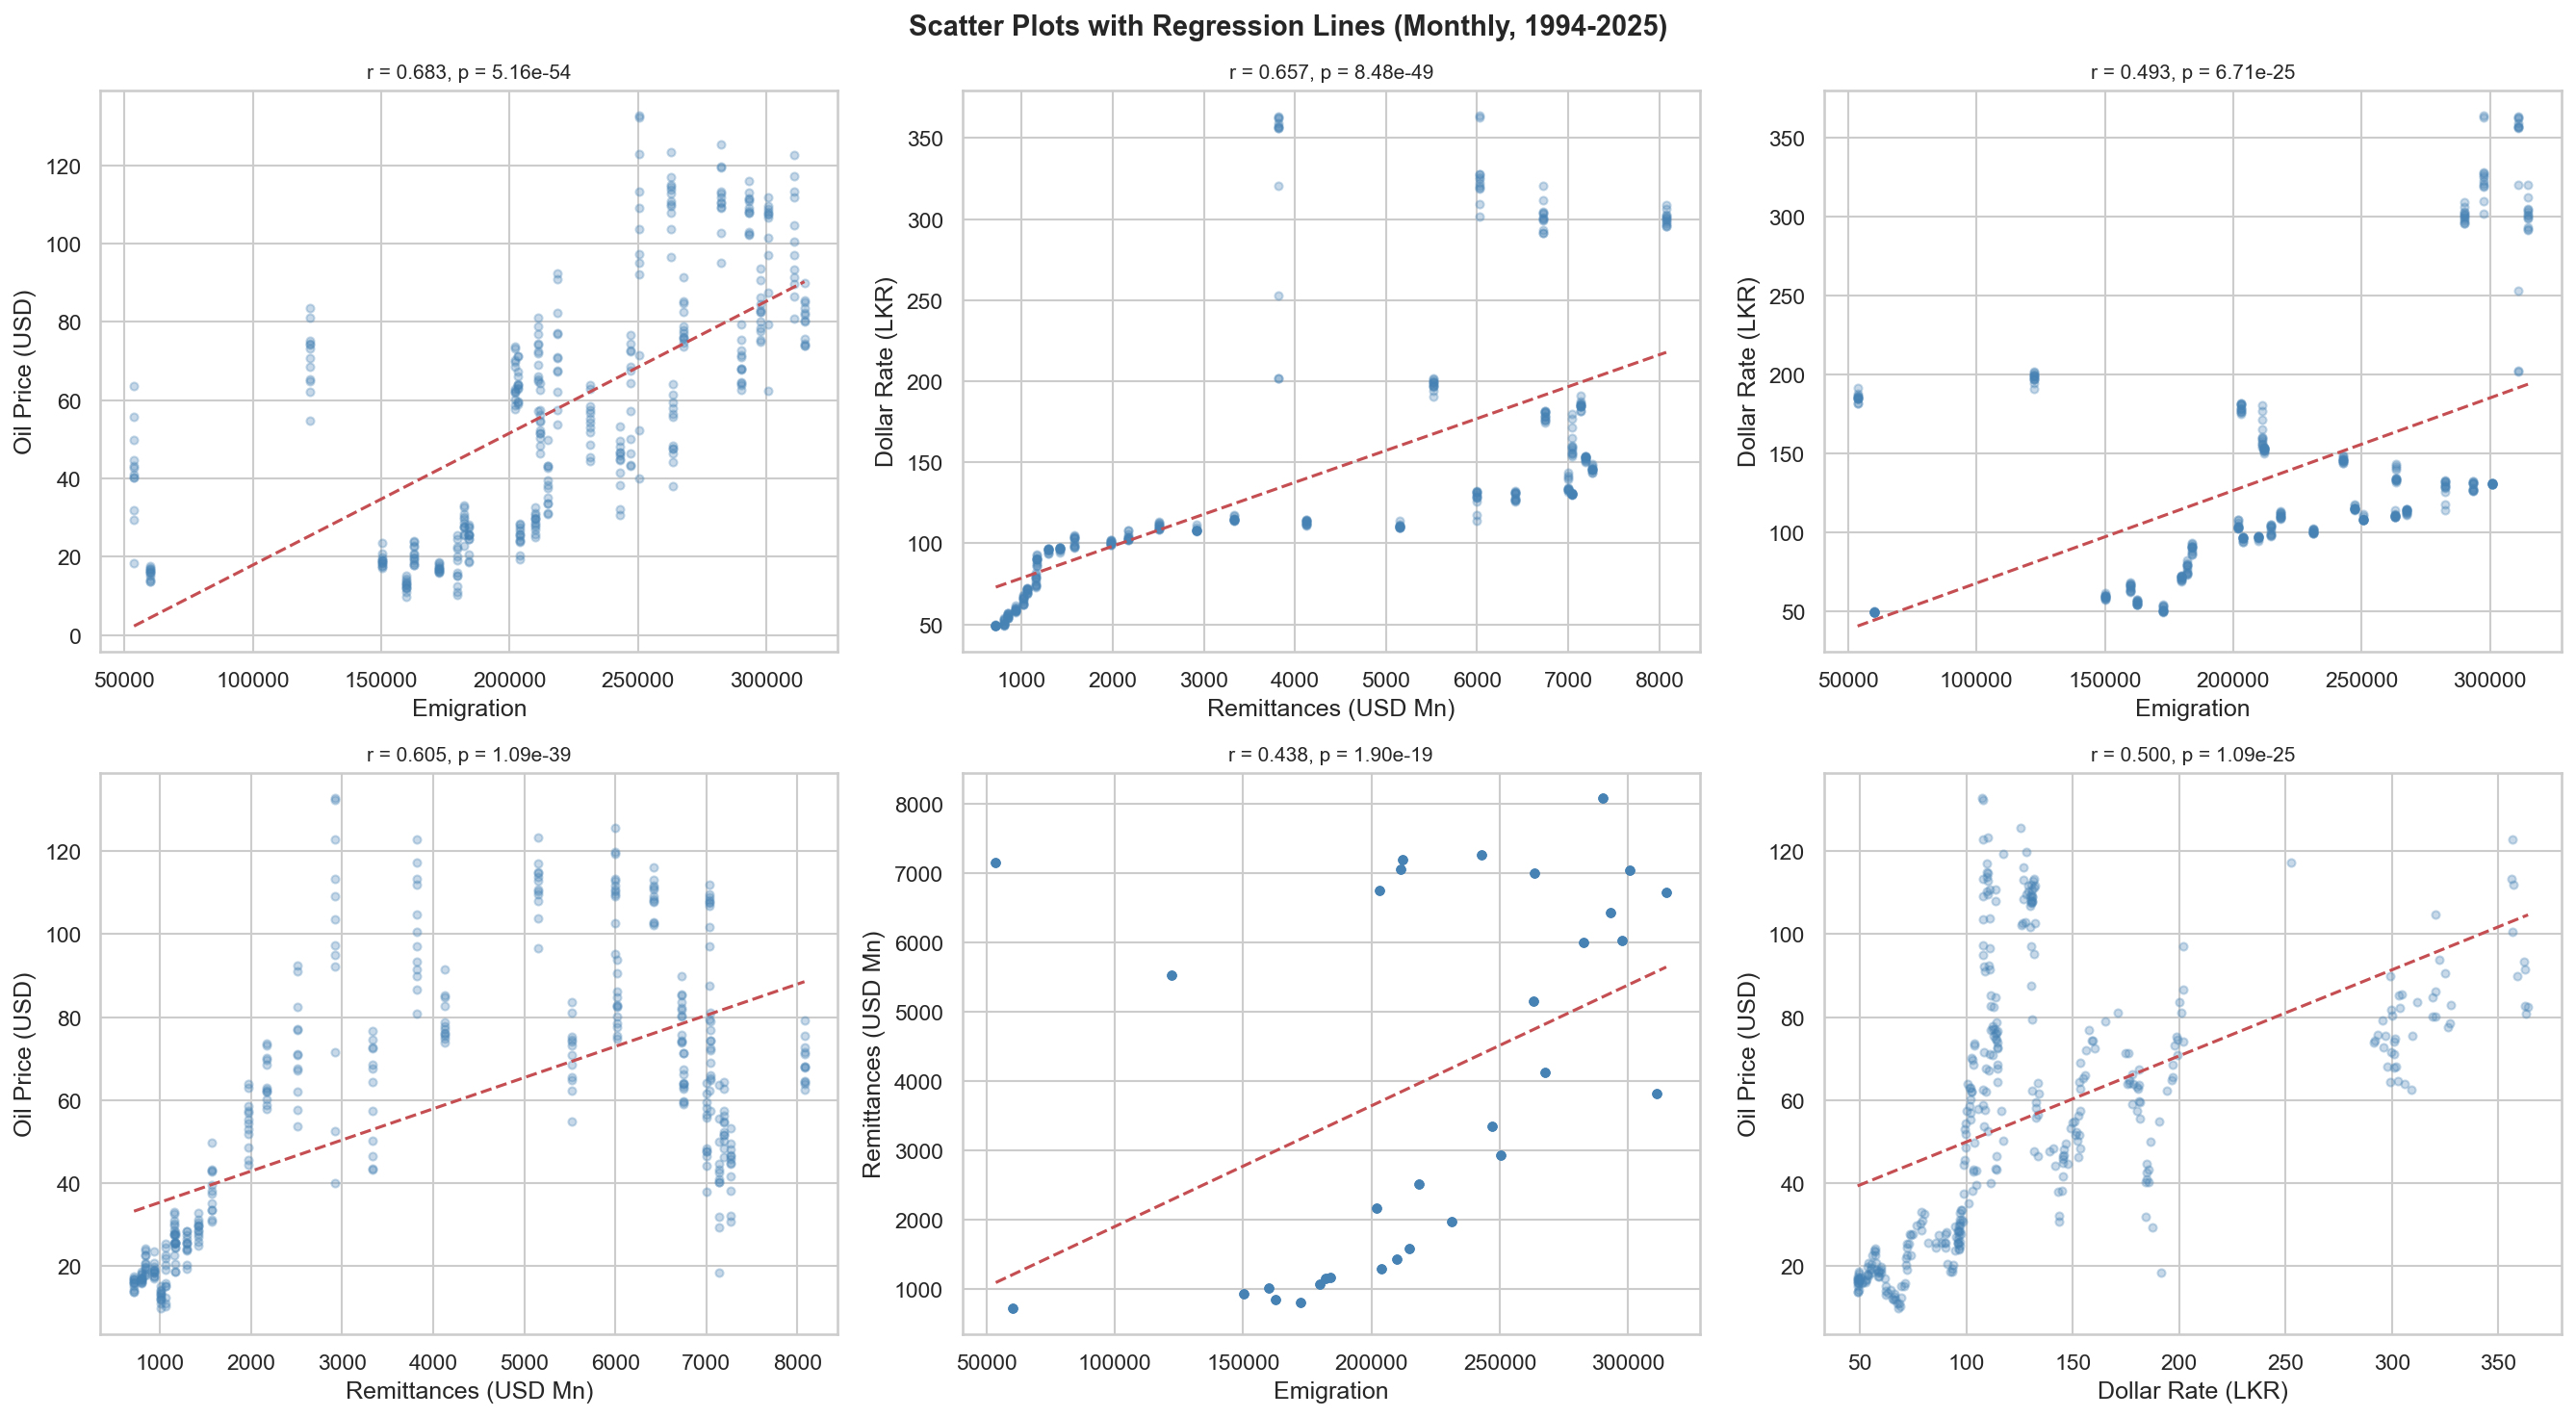

In [9]:
monthly_pairs = [
    ('emigration', 'brent_oil', 'Emigration', 'Oil Price (USD)'),
    ('remittances', 'dollar_rate', 'Remittances (USD Mn)', 'Dollar Rate (LKR)'),
    ('emigration', 'dollar_rate', 'Emigration', 'Dollar Rate (LKR)'),
    ('remittances', 'brent_oil', 'Remittances (USD Mn)', 'Oil Price (USD)'),
    ('emigration', 'remittances', 'Emigration', 'Remittances (USD Mn)'),
    ('dollar_rate', 'brent_oil', 'Dollar Rate (LKR)', 'Oil Price (USD)')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scatter Plots with Regression Lines (Monthly, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (x, y, xlabel, ylabel) in zip(axes.flat, monthly_pairs):
    ax.scatter(monthly[x], monthly[y], alpha=0.3, color='steelblue', s=15)
    z = np.polyfit(monthly[x], monthly[y], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(monthly[x].min(), monthly[x].max(), 100)
    ax.plot(x_line, p_line(x_line), 'r--', linewidth=1.5)
    r, pval = stats.pearsonr(monthly[x], monthly[y])
    ax.set_title(f'r = {r:.3f}, p = {pval:.2e}', fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig('eda_scatter_monthly.png')
plt.show()

## 7. Pair Plots

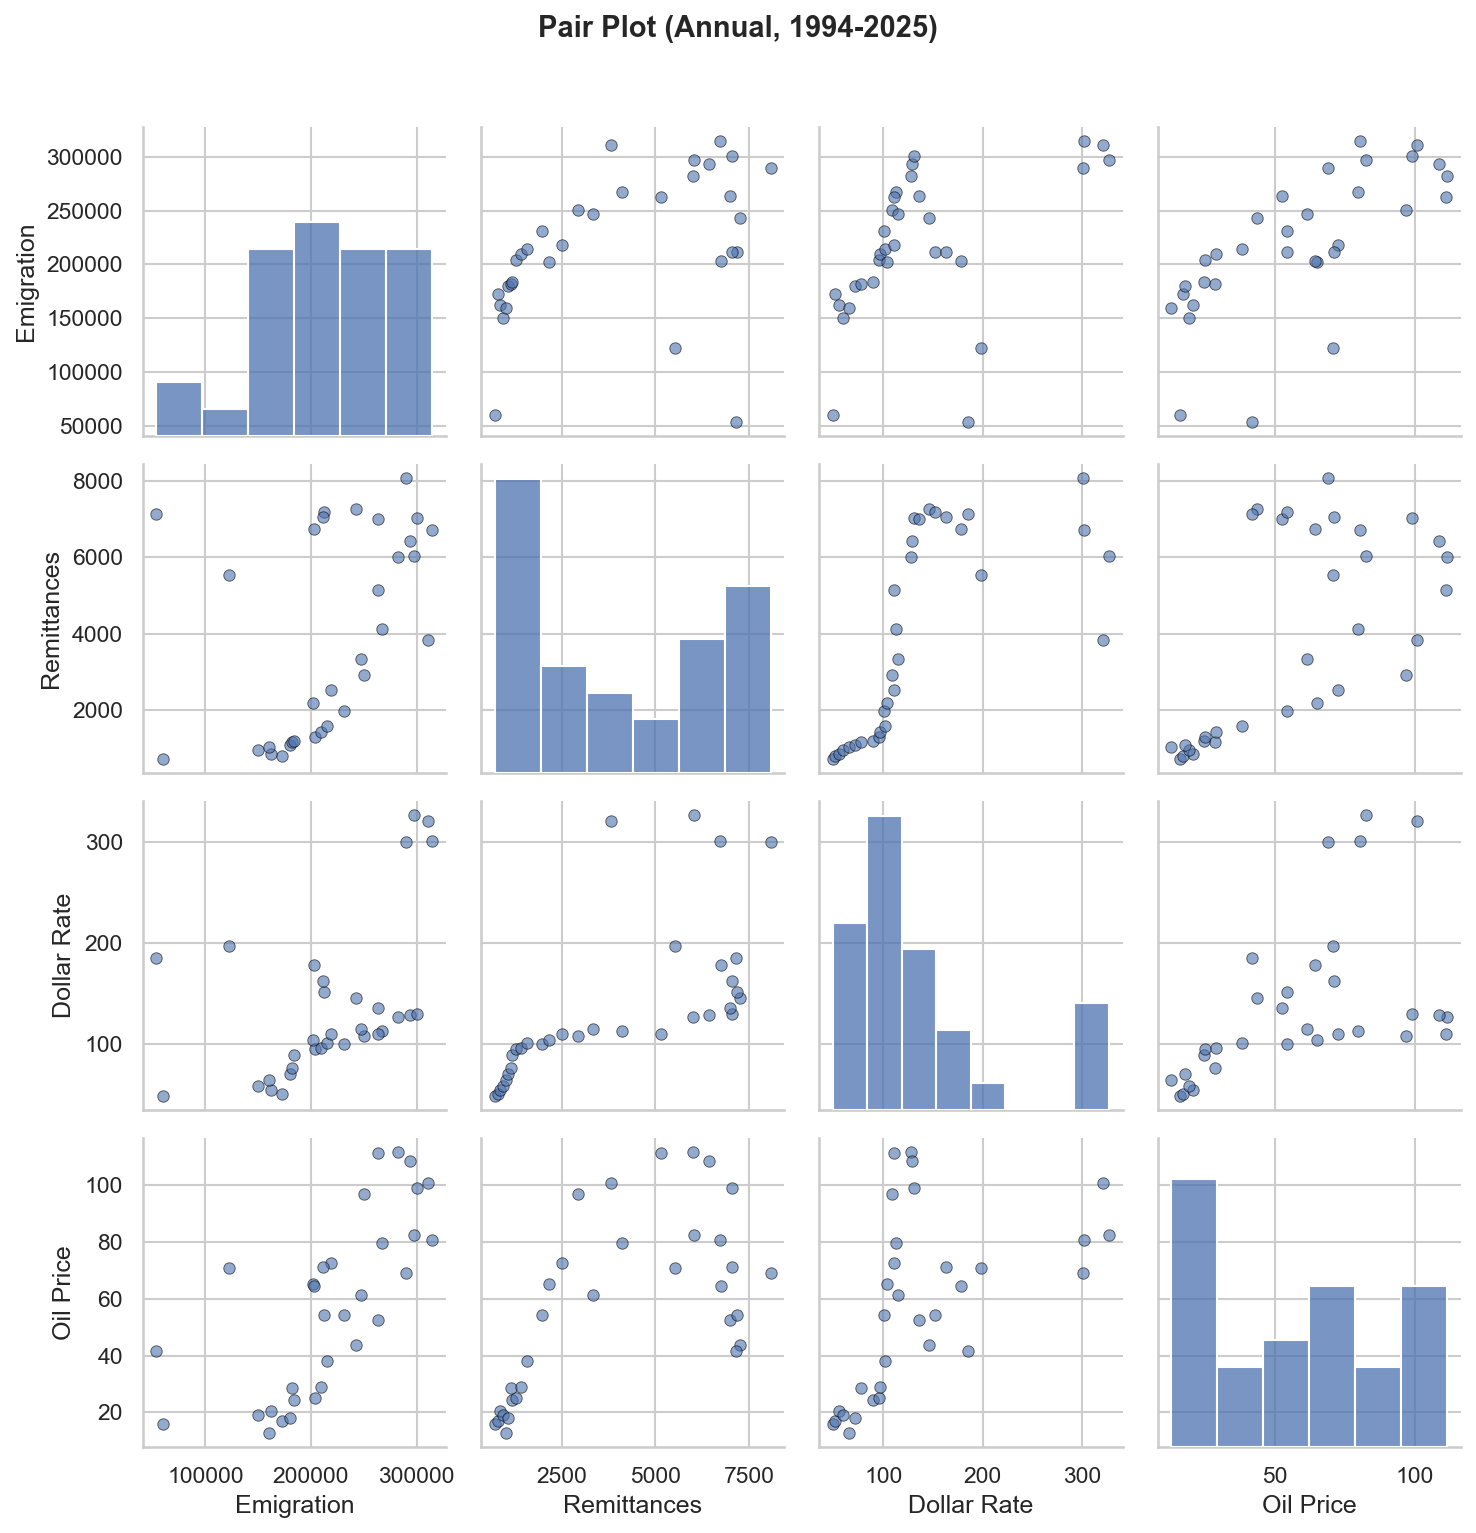

In [10]:
g = sns.pairplot(annual[['emigration','remittances','dollar_rate_annual_avg','brent_oil_annual_avg']].rename(
    columns={'emigration':'Emigration','remittances':'Remittances',
             'dollar_rate_annual_avg':'Dollar Rate','brent_oil_annual_avg':'Oil Price'}),
    diag_kind='hist', plot_kws={'alpha':0.6, 'edgecolor':'black', 's':30})
g.figure.suptitle('Pair Plot (Annual, 1994-2025)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_pairplot_annual.png')
plt.show()

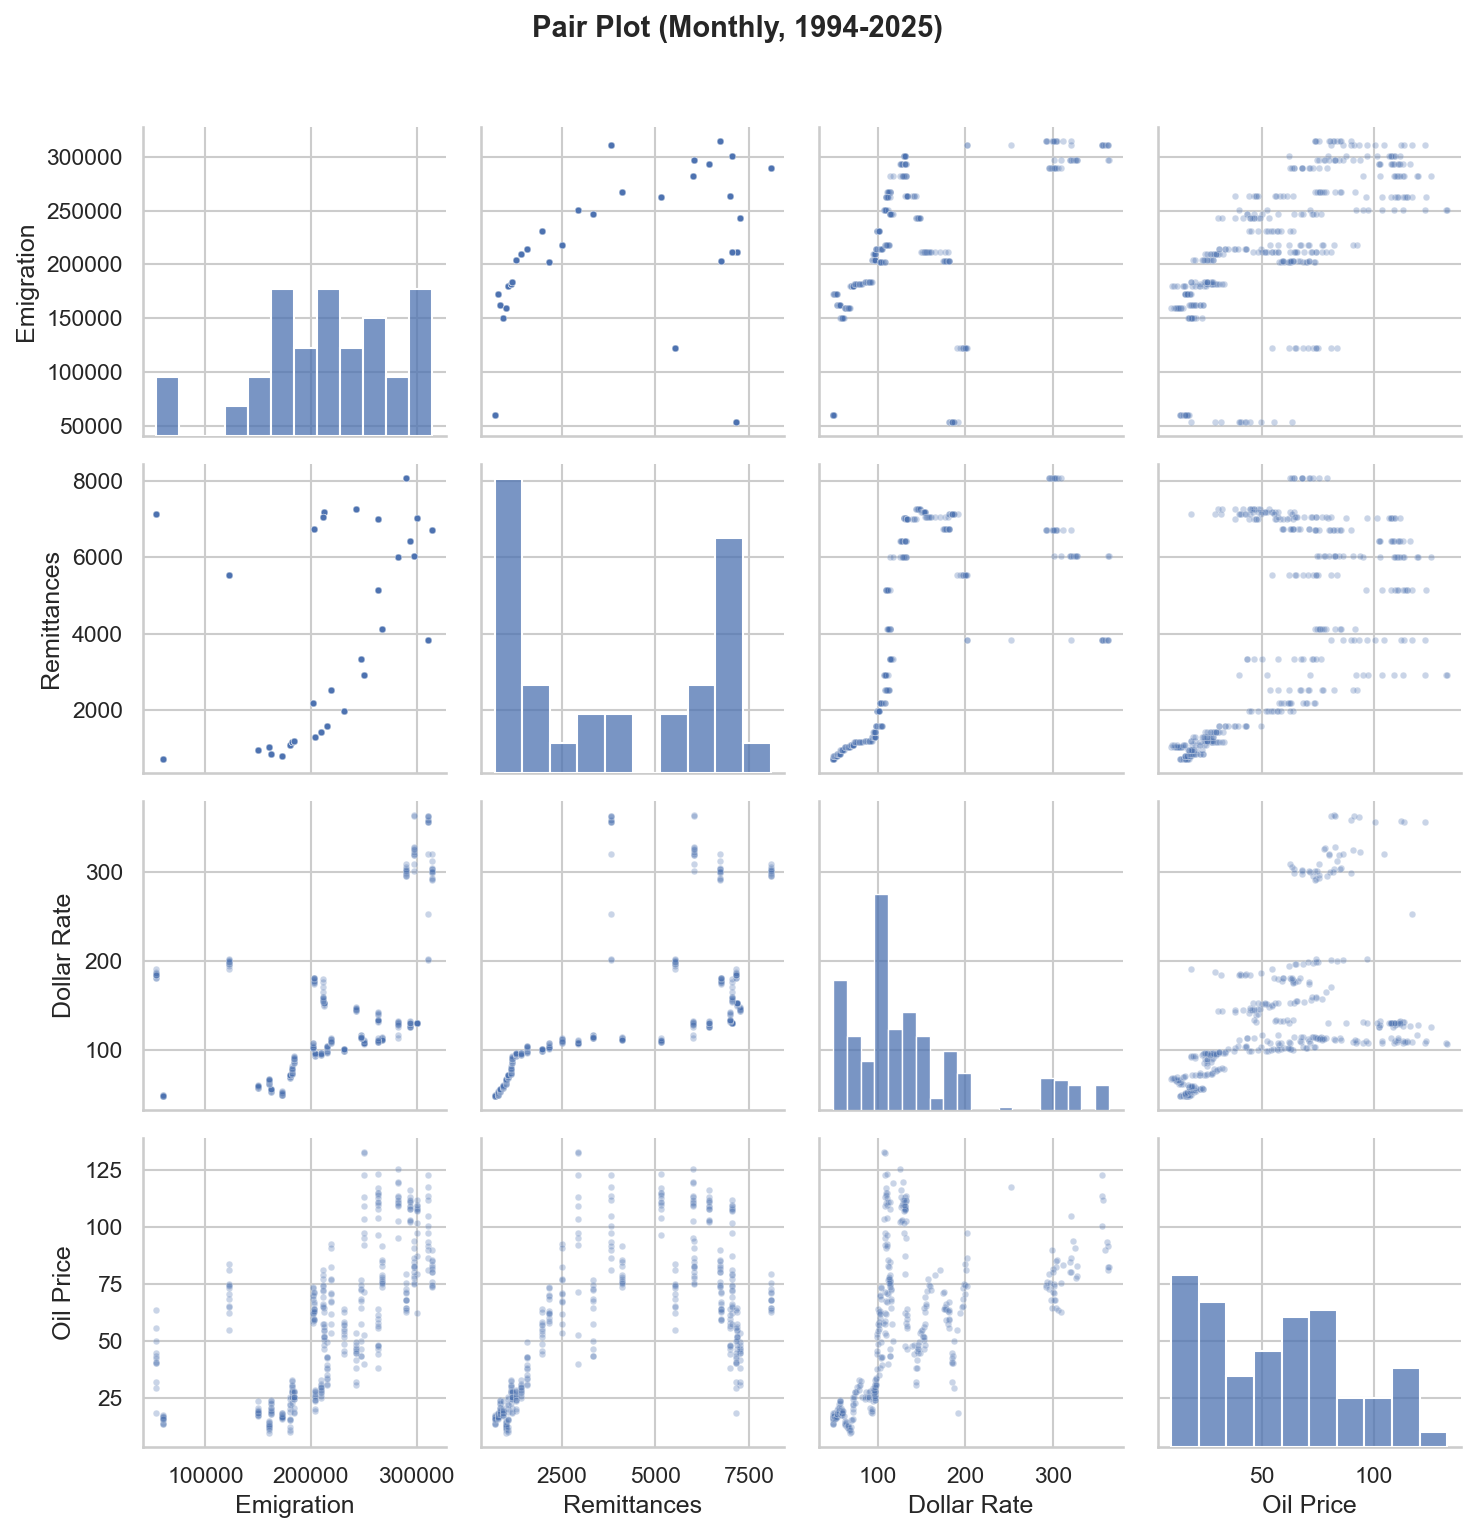

In [11]:
g = sns.pairplot(monthly[['emigration','remittances','dollar_rate','brent_oil']].rename(
    columns={'emigration':'Emigration','remittances':'Remittances',
             'dollar_rate':'Dollar Rate','brent_oil':'Oil Price'}),
    diag_kind='hist', plot_kws={'alpha':0.3, 's':10})
g.figure.suptitle('Pair Plot (Monthly, 1994-2025)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_pairplot_monthly.png')
plt.show()

## 8. Outlier Detection (IQR Method)

In [12]:
def iqr_outliers(series, name, years=None):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (series < lower) | (series > upper)
    outliers = series[mask]
    print(f'\n{name}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Lower fence={lower:.2f}, Upper fence={upper:.2f}')
    print(f'  Outliers: {len(outliers)}')
    if len(outliers) > 0 and years is not None:
        out_years = years[mask].values
        print(f'  Years: {out_years}')
        print(f'  Values: {outliers.values.round(2)}')
    elif len(outliers) > 0:
        print(f'  Values: {outliers.values[:10].round(2)}...')
    return outliers

print('=== IQR Outlier Detection (Annual Dataset, n=32) ===')
for col, name in [('emigration','Emigration'), ('remittances','Remittances'),
                   ('dollar_rate_annual_avg','Dollar Rate'), ('brent_oil_annual_avg','Oil Price')]:
    iqr_outliers(annual[col], name, annual['year'])

=== IQR Outlier Detection (Annual Dataset, n=32) ===

Emigration:
  Q1=181574.75, Q3=264459.00, IQR=82884.25
  Lower fence=57248.38, Upper fence=388785.38
  Outliers: 1
  Years: [2020]
  Values: [53711]

Remittances:
  Q1=1264.50, Q3=6728.39, IQR=5463.88
  Lower fence=-6931.32, Upper fence=14924.21
  Outliers: 0

Dollar Rate:
  Q1=94.22, Q3=154.94, IQR=60.72
  Lower fence=3.15, Upper fence=246.01
  Outliers: 4
  Years: [2022 2023 2024 2025]
  Values: [320.84 327.1  301.7  300.64]

Oil Price:
  Q1=27.63, Q3=79.77, IQR=52.13
  Lower fence=-50.57, Upper fence=157.96
  Outliers: 0


In [13]:
print('=== IQR Outlier Detection (Monthly Dataset, n=384) ===')
for col, name in [('emigration','Emigration'), ('remittances','Remittances'),
                   ('dollar_rate','Dollar Rate'), ('brent_oil','Brent Oil')]:
    iqr_outliers(monthly[col], name)

=== IQR Outlier Detection (Monthly Dataset, n=384) ===

Emigration:
  Q1=181574.75, Q3=264459.00, IQR=82884.25
  Lower fence=57248.38, Upper fence=388785.38
  Outliers: 12
  Values: [53711 53711 53711 53711 53711 53711 53711 53711 53711 53711]...

Remittances:
  Q1=1264.50, Q3=6728.39, IQR=5463.88
  Lower fence=-6931.32, Upper fence=14924.21
  Outliers: 0

Dollar Rate:
  Q1=93.40, Q3=153.63, IQR=60.23
  Lower fence=3.06, Upper fence=243.97
  Outliers: 46
  Values: [252.64 320.33 356.29 356.62 357.13 356.49 358.92 361.89 362.69 363.19]...

Brent Oil:
  Q1=26.99, Q3=78.84, IQR=51.85
  Lower fence=-50.78, Upper fence=156.62
  Outliers: 0


## 9. Period-Stratified Analysis — Three Historical Eras

In [14]:
def assign_era(year):
    if year <= 2008:
        return 'Civil War (1994-2008)'
    elif year <= 2019:
        return 'Post-War (2009-2019)'
    else:
        return 'COVID & Crisis (2020-2025)'

annual['era'] = annual['year'].apply(assign_era)

era_stats = annual.groupby('era')[['emigration','remittances','dollar_rate_annual_avg','brent_oil_annual_avg']].agg(
    ['mean','min','max','count']
).round(2)

print('=== Period-Stratified Statistics (3 Historical Eras) ===')
era_stats

=== Period-Stratified Statistics (3 Historical Eras) ===


emigration                       remittances  \
                                 mean     min     max count        mean   
era                                                                       
COVID & Crisis (2020-2025)  231550.17   53711  314786     6     6217.01   
Civil War (1994-2008)       185452.40   60168  250499    15     1437.48   
Post-War (2009-2019)        253319.18  203087  300703    11     6119.50   

                                                   dollar_rate_annual_avg  \
                                min      max count                   mean   
era                                                                         
COVID & Crisis (2020-2025)  3819.37  8076.20     6                 272.23   
Civil War (1994-2008)        715.19  2924.50    15                  82.25   
Post-War (2009-2019)        3336.70  7261.85    11                 136.41   

                                                 brent_oil_annual_avg         \
                               min     max count                 mean    min   
era                                                                            
COVID & Crisis (2020-2025)  185.28  327.10     6                74.22  41.76   
Civil War (1994-2008)        49.17  110.58    15                35.81  12.78   
Post-War (2009-2019)        110.48  178.57    11                77.92  43.55   

                                          
                               max count  
era                                       
COVID & Crisis (2020-2025)  100.78     6  
Civil War (1994-2008)        96.85    15  
Post-War (2009-2019)        111.65    11

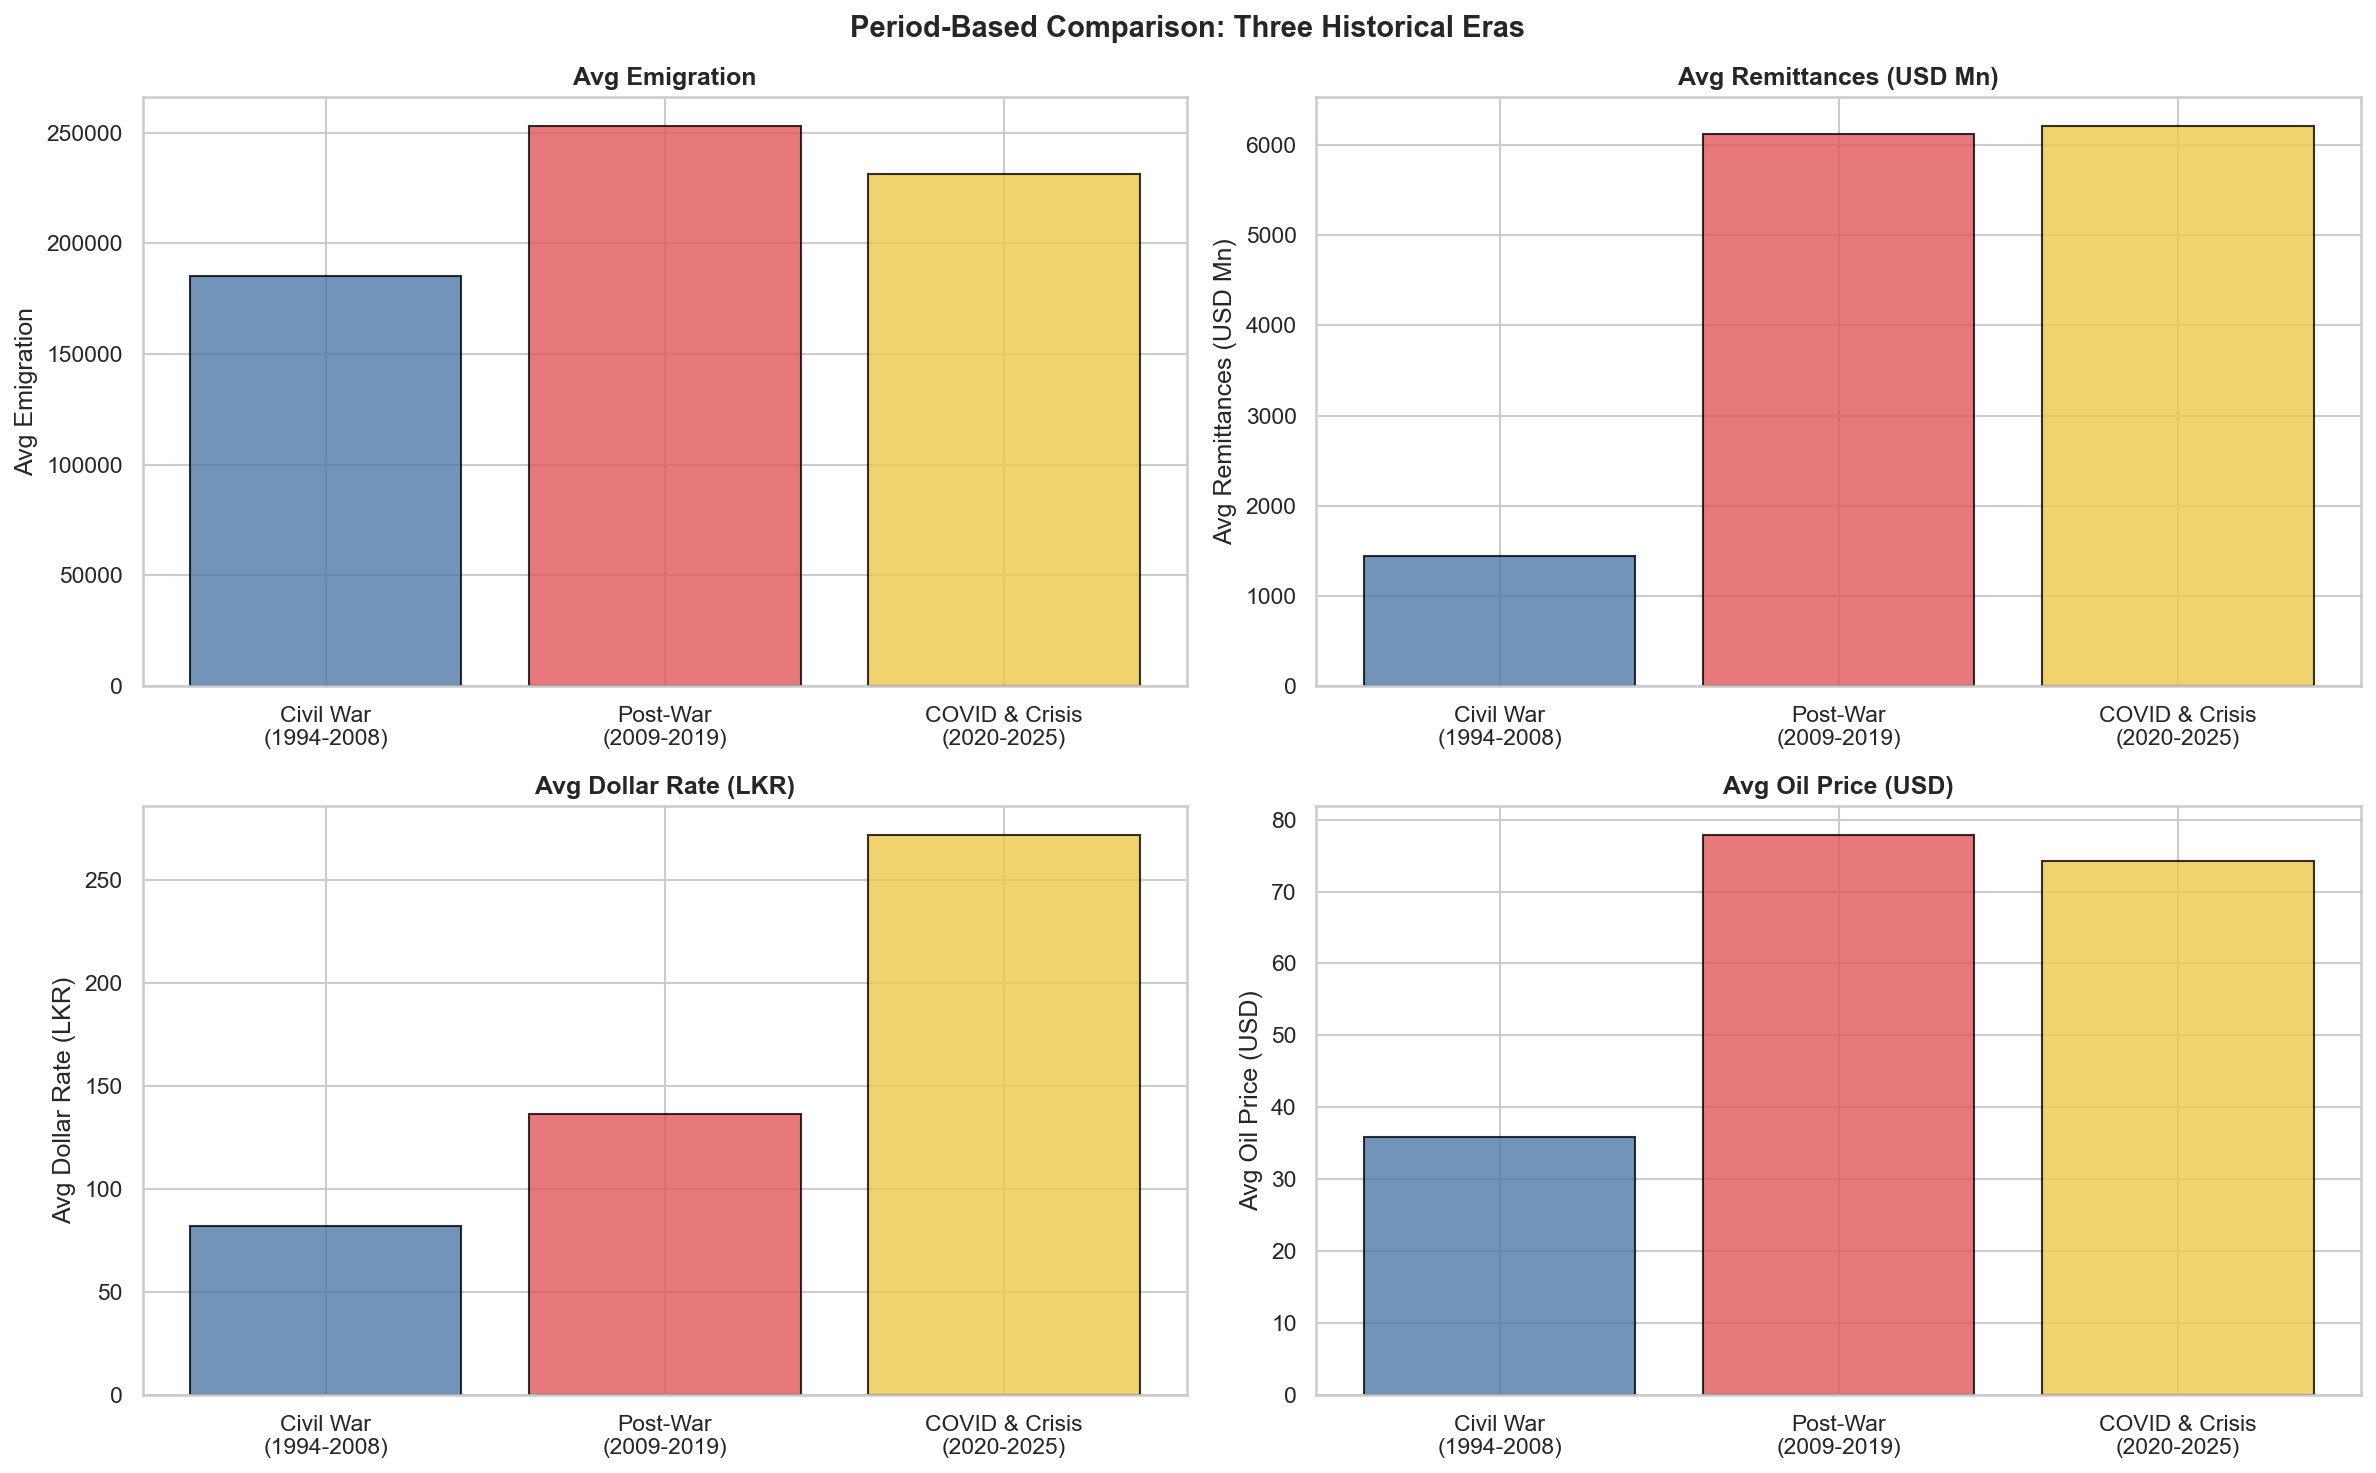

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Period-Based Comparison: Three Historical Eras', fontsize=14, fontweight='bold')

era_order = ['Civil War (1994-2008)', 'Post-War (2009-2019)', 'COVID & Crisis (2020-2025)']
colors = ['#4e79a7', '#e15759', '#edc948']
era_means = annual.groupby('era')[['emigration','remittances','dollar_rate_annual_avg','brent_oil_annual_avg']].mean()

vars_plot = [
    ('emigration', 'Avg Emigration'),
    ('remittances', 'Avg Remittances (USD Mn)'),
    ('dollar_rate_annual_avg', 'Avg Dollar Rate (LKR)'),
    ('brent_oil_annual_avg', 'Avg Oil Price (USD)')
]

for ax, (col, title) in zip(axes.flat, vars_plot):
    vals = [era_means.loc[e, col] if e in era_means.index else 0 for e in era_order]
    short_labels = ['Civil War\n(1994-2008)', 'Post-War\n(2009-2019)', 'COVID & Crisis\n(2020-2025)']
    ax.bar(short_labels, vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(title)

plt.tight_layout()
plt.savefig('eda_period_comparison.png')
plt.show()

## 10. Cross-Lag Correlation Analysis (Monthly, n=384)

In [16]:
lags = [0, 1, 2, 3, 6, 9, 12]

lag_pairs = [
    ('dollar_rate', 'remittances', 'Dollar Rate (Lagged) -> Remittances'),
    ('dollar_rate', 'emigration', 'Dollar Rate (Lagged) -> Emigration'),
    ('brent_oil', 'emigration', 'Brent Oil (Lagged) -> Emigration'),
]

print('=== Cross-Lag Correlation Analysis ===')
print('Purpose: Test whether changes in one variable systematically lead changes in another.')

lag_results = {}
for x_col, y_col, title in lag_pairs:
    print(f'\n--- {title} ---')
    print(f'{"Lag (months)":>15s} {"Pearson r":>12s} {"p-value":>15s} {"Sig":>5s}')
    print('-' * 50)
    results = []
    for lag in lags:
        if lag == 0:
            x_data = monthly[x_col]
            y_data = monthly[y_col]
        else:
            x_data = monthly[x_col].iloc[:-lag]
            y_data = monthly[y_col].iloc[lag:]
        r, p = stats.pearsonr(x_data.values, y_data.values)
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        print(f'{"Lag " + str(lag):>15s} {r:12.4f} {p:15.6e} {sig:>5s}')
        results.append({'lag': lag, 'r': r, 'p': p})
    lag_results[title] = results

=== Cross-Lag Correlation Analysis ===
Purpose: Test whether changes in one variable systematically lead changes in another.

--- Dollar Rate (Lagged) -> Remittances ---
   Lag (months)    Pearson r         p-value   Sig
--------------------------------------------------
          Lag 0       0.6570    8.477043e-49   ***
          Lag 1       0.6596    3.482483e-49   ***
          Lag 2       0.6625    1.303710e-49   ***
          Lag 3       0.6654    4.537847e-50   ***
          Lag 6       0.6752    1.232330e-51   ***
          Lag 9       0.6844    3.910364e-53   ***
         Lag 12       0.6853    6.752076e-53   ***

--- Dollar Rate (Lagged) -> Emigration ---
   Lag (months)    Pearson r         p-value   Sig
--------------------------------------------------
          Lag 0       0.4929    6.711992e-25   ***
          Lag 1       0.4890    2.059883e-24   ***
          Lag 2       0.4850    6.253800e-24   ***
          Lag 3       0.4808    1.966641e-23   ***
          Lag 6      

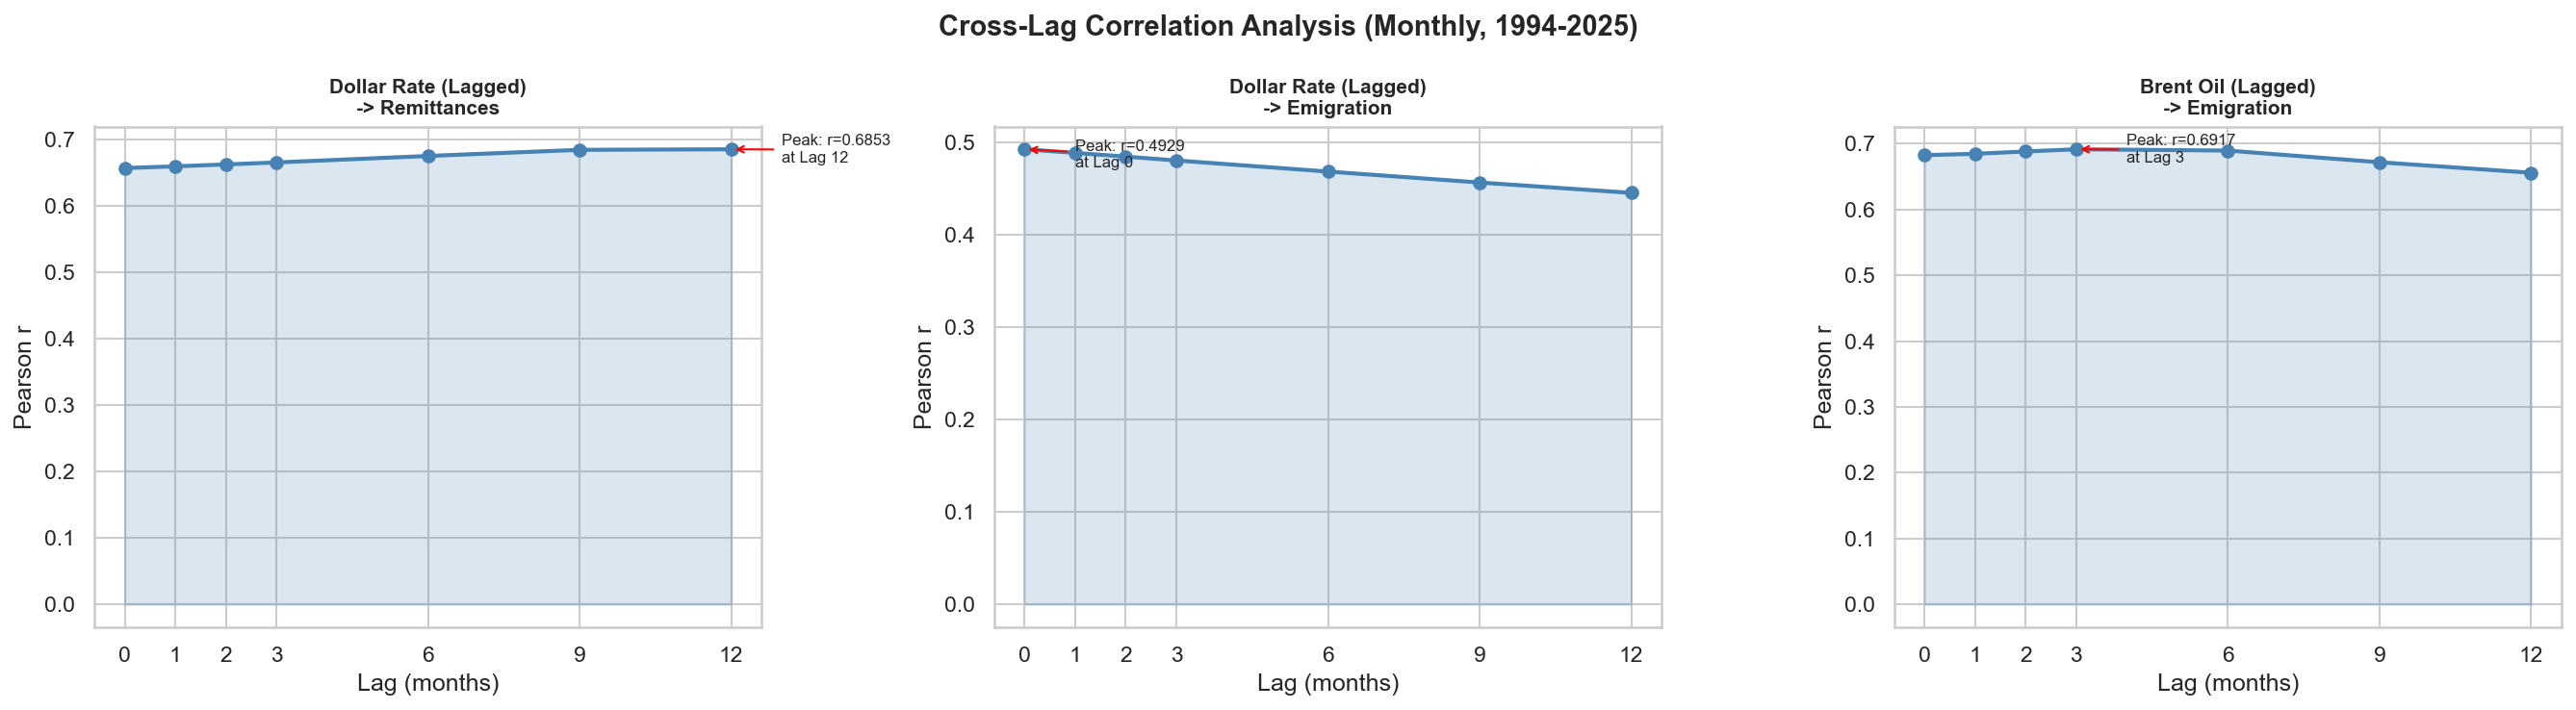

In [17]:
# Visualize lag correlations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cross-Lag Correlation Analysis (Monthly, 1994-2025)', fontsize=14, fontweight='bold')

for ax, (title, results) in zip(axes, lag_results.items()):
    lag_vals = [r['lag'] for r in results]
    r_vals = [r['r'] for r in results]
    ax.plot(lag_vals, r_vals, marker='o', color='steelblue', linewidth=2, markersize=6)
    ax.fill_between(lag_vals, r_vals, alpha=0.2, color='steelblue')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Pearson r')
    short_title = title.split(' -> ')
    ax.set_title(f'{short_title[0]}\n-> {short_title[1]}', fontsize=10, fontweight='bold')
    ax.set_xticks(lag_vals)
    # Find peak
    peak_idx = np.argmax(r_vals)
    ax.annotate(f'Peak: r={r_vals[peak_idx]:.4f}\nat Lag {lag_vals[peak_idx]}',
                xy=(lag_vals[peak_idx], r_vals[peak_idx]),
                xytext=(lag_vals[peak_idx]+1, r_vals[peak_idx]-0.02),
                fontsize=8, ha='left',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('eda_lag_correlation.png')
plt.show()

## 11. Full Correlation Matrix — All Annual Variables

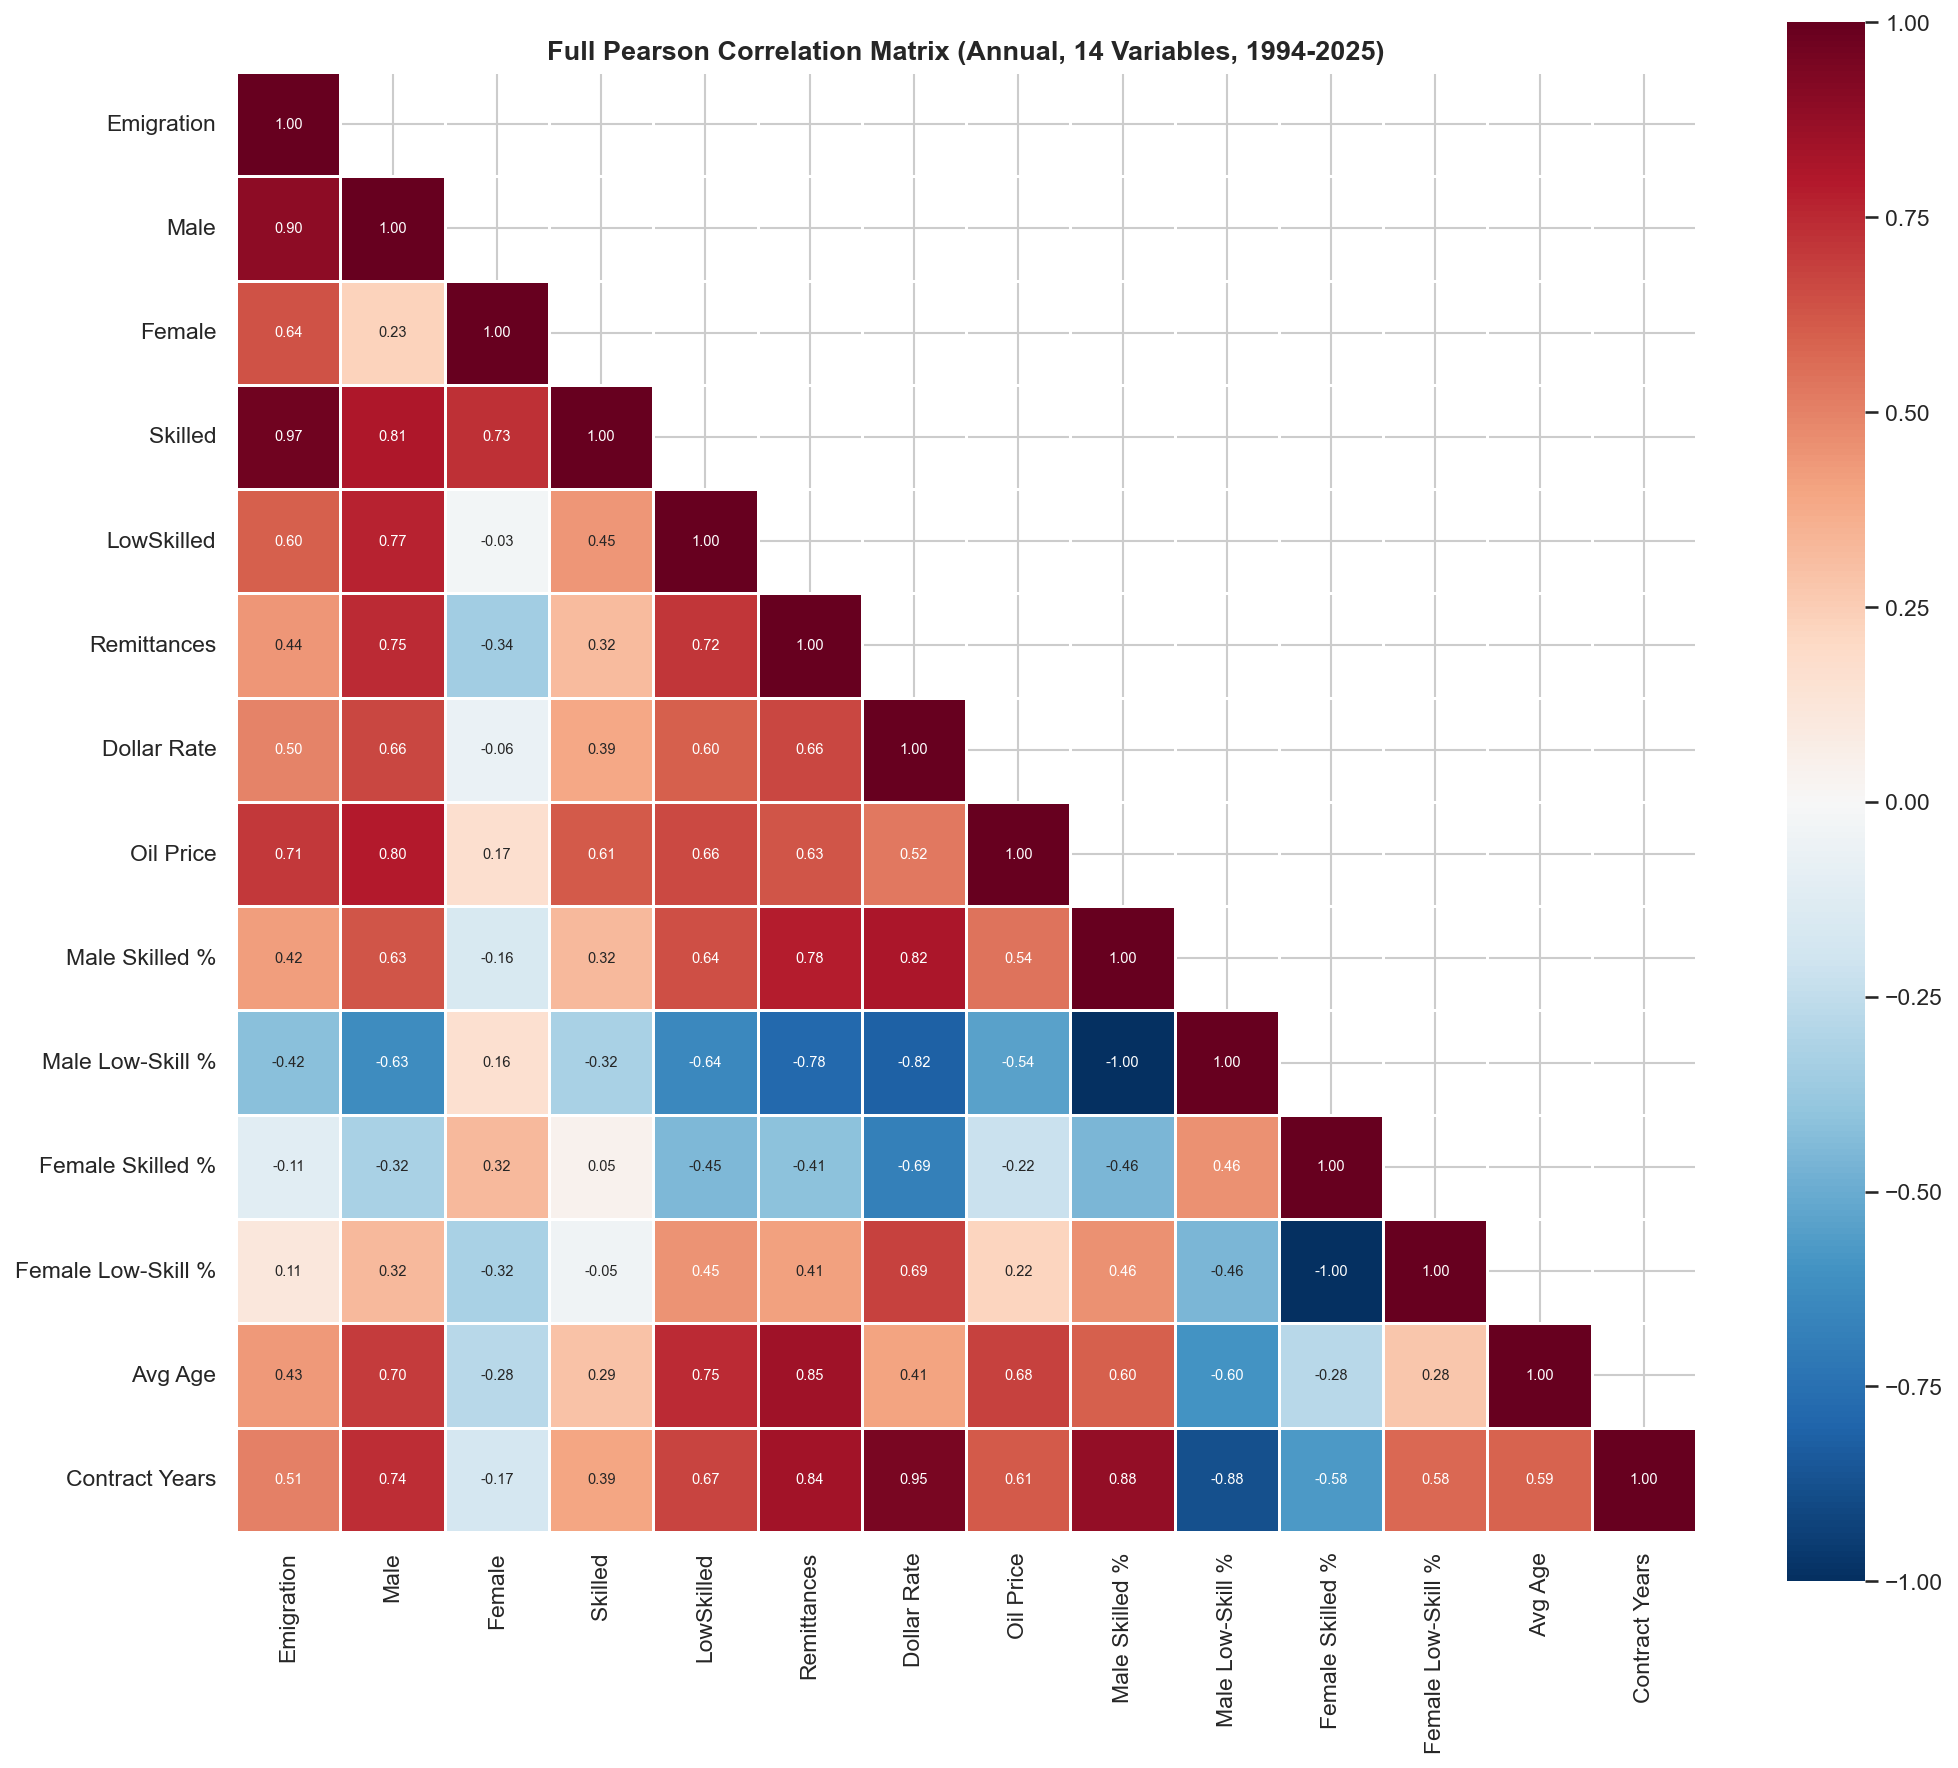

In [18]:
full_cols = ['emigration','male','female','skilled','lowskilled',
             'remittances','dollar_rate_annual_avg','brent_oil_annual_avg',
             'male_skilled_pct_annual','male_lowskilled_pct_annual',
             'female_skilled_pct_annual','female_lowskilled_pct_annual',
             'avg_age_annual','avg_contract_years_annual']

full_labels = ['Emigration','Male','Female','Skilled','LowSkilled',
               'Remittances','Dollar Rate','Oil Price',
               'Male Skilled %','Male Low-Skill %',
               'Female Skilled %','Female Low-Skill %',
               'Avg Age','Contract Years']

full_data = annual[full_cols].copy()
full_data.columns = full_labels

full_corr = full_data.corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(full_corr, dtype=bool), k=1)
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, mask=mask, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Full Pearson Correlation Matrix (Annual, 14 Variables, 1994-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_full_corr_matrix.png')
plt.show()

In [19]:
# Print strongest correlations (excluding mathematical complements)
corr_pairs = []
for i in range(len(full_labels)):
    for j in range(i+1, len(full_labels)):
        r = full_corr.iloc[i, j]
        corr_pairs.append((full_labels[i], full_labels[j], r, abs(r)))

corr_pairs.sort(key=lambda x: x[3], reverse=True)

print('=== Strongest Correlations (by |r|) ===')
print()
print('Extremely Strong (|r| >= 0.90):')
for v1, v2, r, absr in corr_pairs:
    if absr >= 0.90:
        print(f'  {v1:20s} <-> {v2:20s}: r = {r:+.3f}')

print('\nStrong (0.70 <= |r| < 0.90):')
for v1, v2, r, absr in corr_pairs:
    if 0.70 <= absr < 0.90:
        print(f'  {v1:20s} <-> {v2:20s}: r = {r:+.3f}')

print('\nModerate (0.40 <= |r| < 0.70):')
for v1, v2, r, absr in corr_pairs:
    if 0.40 <= absr < 0.70:
        print(f'  {v1:20s} <-> {v2:20s}: r = {r:+.3f}')

=== Strongest Correlations (by |r|) ===

Extremely Strong (|r| >= 0.90):
  Male Skilled %       <-> Male Low-Skill %    : r = -1.000
  Female Skilled %     <-> Female Low-Skill %  : r = -1.000
  Emigration           <-> Skilled             : r = +0.973
  Dollar Rate          <-> Contract Years      : r = +0.951

Strong (0.70 <= |r| < 0.90):
  Emigration           <-> Male                : r = +0.898
  Male Skilled %       <-> Contract Years      : r = +0.878
  Male Low-Skill %     <-> Contract Years      : r = -0.878
  Remittances          <-> Avg Age             : r = +0.847
  Remittances          <-> Contract Years      : r = +0.837
  Dollar Rate          <-> Male Skilled %      : r = +0.819
  Dollar Rate          <-> Male Low-Skill %    : r = -0.819
  Male                 <-> Skilled             : r = +0.808
  Male                 <-> Oil Price           : r = +0.796
  Remittances          <-> Male Skilled %      : r = +0.783
  Remittances          <-> Male Low-Skill %    : r = -0.7

## 12. Summary Table — All Significant Correlations (Annual, n=32)

In [20]:
# Create summary of all key correlations with p-values
summary_pairs = [
    ('emigration', 'remittances', 'Emigration', 'Remittances'),
    ('emigration', 'dollar_rate_annual_avg', 'Emigration', 'Dollar Rate'),
    ('emigration', 'brent_oil_annual_avg', 'Emigration', 'Oil Price'),
    ('remittances', 'dollar_rate_annual_avg', 'Remittances', 'Dollar Rate'),
    ('remittances', 'brent_oil_annual_avg', 'Remittances', 'Oil Price'),
    ('dollar_rate_annual_avg', 'brent_oil_annual_avg', 'Dollar Rate', 'Oil Price'),
    ('avg_contract_years_annual', 'dollar_rate_annual_avg', 'Contract Yrs', 'Dollar Rate'),
    ('male', 'brent_oil_annual_avg', 'Male', 'Oil Price'),
    ('avg_age_annual', 'remittances', 'Avg Age', 'Remittances'),
    ('male_skilled_pct_annual', 'dollar_rate_annual_avg', 'Male Skilled %', 'Dollar Rate'),
    ('female_skilled_pct_annual', 'dollar_rate_annual_avg', 'Female Skilled %', 'Dollar Rate'),
]

rows = []
for c1, c2, n1, n2 in summary_pairs:
    r, p = stats.pearsonr(annual[c1], annual[c2])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    rows.append({'Pair': f'{n1} <-> {n2}', 'r': round(r, 4), 'p-value': p, 'Sig': sig})

summary_df = pd.DataFrame(rows)
print('=== Summary Table: Key Annual Correlations ===')
summary_df

=== Summary Table: Key Annual Correlations ===


,Pair,r,p-value,Sig
0,Emigration <-> Remittances,0.4382,1.212293e-02,*
1,Emigration <-> Dollar Rate,0.4986,3.679634e-03,**
2,Emigration <-> Oil Price,0.7070,6.081734e-06,***
3,Remittances <-> Dollar Rate,0.6645,3.352990e-05,***
4,Remittances <-> Oil Price,0.6264,1.253852e-04,***
5,Dollar Rate <-> Oil Price,0.5236,2.101667e-03,**
6,Contract Yrs <-> Dollar Rate,0.9513,7.126504e-17,***
7,Male <-> Oil Price,0.7959,5.183961e-08,***
8,Avg Age <-> Remittances,0.8466,1.024085e-09,***
9,Male Skilled % <-> Dollar Rate,0.8187,1.028604e-08,***


## 13. Summary of EDA Findings

**Finding 1 — All correlations are positive and significant:**
All 6 pairwise Pearson correlations among the four primary variables are positive and statistically significant at α=0.05 (annual) and α=0.001 (monthly), consistent across both data granularities.

**Finding 2 — Gulf labour market is the primary system driver:**
Emigration ↔ Oil Price (r=0.707, p<0.001) is the strongest contemporaneous relationship. The lag analysis shows a 3-month peak (r=0.692), consistent with the typical visa-processing timeline.

**Finding 3 — Rupee weakness is a strong push factor:**
Dollar Rate correlates strongly with contract years (r=0.951), remittances (r=0.665), and male skilled % (r=0.819). The lag analysis shows remittance correlation increases with lag length (r rises from 0.657 at Lag 0 to 0.685 at Lag 12).

**Finding 4 — 2022 economic crisis is a regime change, not an outlier:**
IQR flags 2022–2025 as 4 consecutive exchange-rate outliers. The simultaneous emigration spike confirms a structural break in system dynamics.

**Finding 5 — COVID-19 (2020) as an independent structural shock:**
Emigration collapsed 73.55% while remittances rose 5.73% — demonstrating that the existing diaspora is a counter-cyclically stable remittance source.

**Finding 6 — Extended variable insights:**
Contract years ↔ Dollar Rate (r=0.951) is the strongest non-trivial correlation, supporting the 'desperation migration' hypothesis. Male emigration correlates more strongly with oil prices (r=0.796) than total emigration (r=0.707).